In [ ]:
#%% imports and file settings
import os, sys
import matplotlib.pyplot as plt

# Add the parent directory to the Python path
parent_dir = os.getcwd()
sys.path.insert(0, parent_dir)

# Now import the modules from the src directory
import src.percolator_file_functions as pff
import src.fdr_functions as fdrf

# TODO:
# - make intervals for replicates
# - automatically calculate all searchengines

In [ ]:
base_path = "/mnt/data/pipeline-of-identifications/publication/PXD023217-CAMPI/DB1-entrap/"
entr_fold = 3

searchengine = "msamanda"
base_path = base_path + searchengine + "/"
if searchengine == "comet":
    se_score = "neg_ln_comet_expectation_value"
elif searchengine == "maxquant":
    se_score = "maxquant_Score"
elif searchengine == "msamanda":
    se_score = "amanda_score"
elif searchengine == "msfragger":
    se_score = "neg_ln_msfragger_expect"
elif searchengine == "msgfplus":
    se_score = "ln_msgf_specevalue"
elif searchengine == "sage":
    se_score = "sage_discriminant_score"
elif searchengine == "xtandem":
    se_score = "neg_ln_xtandem_expect"

lst = os.listdir(base_path)
lst.sort()

for f in lst:
    if f.endswith(".psm_utils.pin"):
        pin_file = f"{base_path}/{f}"
    if f.endswith(".psm_utils.pout"):
        pout_file = f"{base_path}/{f}"
    if f.endswith(".ms2rescore.corrected.pin"):
        pin_file_rescored = f"{base_path}/{f}"
    if f.endswith(".ms2rescore.corrected.pout"):
        pout_file_rescored = f"{base_path}/{f}"

print(pin_file)
print(pout_file)
print(pin_file_rescored)
print(pout_file_rescored)

# Data from original search only
pin_df = pff.parse_percolator_pin(pin_file)
tda_df = pin_df[["Label", se_score, "Peptide"]].copy()
tda_df["proteinIds"] = pin_df["Proteins"].copy()
tda_df = fdrf.calculate_fdr(tda_df, se_score)
# filter out the decoys
tda_df = tda_df[tda_df["Label"] == 1]
tda_df["proteinIds"] = tda_df["proteinIds"].apply(
    lambda ids: ids.split("\t") if isinstance(ids, str) else ids
)

## data from percolator
percolated_df = pff.read_enriched_pout_with_pin_data(pout_file, pin_file)

## data from percolator with rescoring
percolated_rescored_df = pff.read_enriched_pout_with_pin_data(pout_file_rescored, pin_file_rescored)


/mnt/data/pipeline-of-identifications/publication/PXD023217-CAMPI/DB1-entrap/msamanda//S07_msamanda.csv.psm_utils.pin
/mnt/data/pipeline-of-identifications/publication/PXD023217-CAMPI/DB1-entrap/msamanda//S07_msamanda.csv.psm_utils.pout
/mnt/data/pipeline-of-identifications/publication/PXD023217-CAMPI/DB1-entrap/msamanda//S07_msamanda.csv.psm_utils.enhanced.tsv.ms2rescore.corrected.pin
/mnt/data/pipeline-of-identifications/publication/PXD023217-CAMPI/DB1-entrap/msamanda//S07_msamanda.csv.psm_utils.enhanced.tsv.ms2rescore.corrected.pout


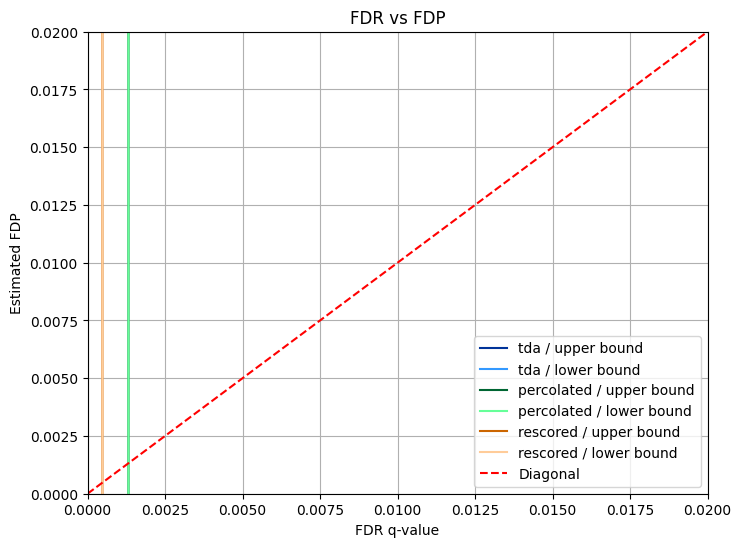

In [17]:
fdp_by = "q-value"
tda_df = fdrf.calculate_fdp(tda_df, fdp_by=fdp_by, entr_fold=entr_fold, lowerscorebetter=True)
percolated_df = fdrf.calculate_fdp(percolated_df, fdp_by=fdp_by, entr_fold=entr_fold, lowerscorebetter=True)
percolated_rescored_df = fdrf.calculate_fdp(percolated_rescored_df, fdp_by=fdp_by, entr_fold=entr_fold, lowerscorebetter=True)

# plotting
plt.figure(figsize=(8, 6))

plt.xlabel("FDR q-value")
plt.ylabel("Estimated FDP")
plt.title("FDR vs FDP")
plt.grid(True)

plt.xlim(0, 0.02)
plt.ylim(0, 0.02)

plt.plot(tda_df["q-value"], tda_df["fdp_ub"], label='tda / upper bound', color='#003399')
plt.plot(tda_df["q-value"], tda_df["fdp_lb"], label='tda / lower bound', color='#3399FF')

plt.plot(percolated_df["q-value"], percolated_df["fdp_ub"], label='percolated / upper bound', color='#006633')
plt.plot(percolated_df["q-value"], percolated_df["fdp_lb"], label='percolated / lower bound', color='#66FF99')

plt.plot(percolated_rescored_df["q-value"], percolated_rescored_df["fdp_ub"], label='rescored / upper bound', color='#CC6600')
plt.plot(percolated_rescored_df["q-value"], percolated_rescored_df["fdp_lb"], label='rescored / lower bound', color='#FFCC99')

# Add a diagonal line
max_diagonal = max(max(tda_df["q-value"]), max(tda_df["fdp_ub"]), max(tda_df["fdp_lb"]))
plt.plot([0, max_diagonal], [0, max_diagonal], color='red', linestyle='--', label='Diagonal')

# Add legend
plt.legend()

plt.show()

In [27]:
pin_df = pff.parse_percolator_pin(pin_file)
tda_df = pin_df[["Label", se_score, "Peptide"]].copy()
tda_df["proteinIds"] = pin_df["Proteins"].copy()
tda_df = fdrf.calculate_fdr(tda_df, se_score)
# filter out the decoys
tda_df = tda_df[tda_df["Label"] == 1]
tda_df["proteinIds"] = tda_df["proteinIds"].apply(
    lambda ids: ids.split("\t") if isinstance(ids, str) else ids
)

fdp_by = "q-value"
tda_df = fdrf.calculate_fdp(tda_df, fdp_by=fdp_by, entr_fold=entr_fold, lowerscorebetter=True)
tda_df


,Label,amanda_score,Peptide,proteinIds,is_decoy,q-value,is_entrapment,fdp_ub,fdp_lb
SpecId,,,,,,,,,
36417,1,940.105332,.TGDDAGDGTTTATVLAQAIVAEGLKNVTAGASPMDIKR.,"[igc|MH0378_GL0061463, igc|V1.UC26-4_GL0095949...",False,0.000000,False,0.000000,0.000000
34601,1,929.144977,.FKYFLSQAIGC[UNIMOD:Carbamidomethyl]NANEVEGMVI...,"[igc|V1.FI37_GL0140014, igc|O2.UC48-0_GL0217544]",False,0.000000,False,0.000000,0.000000
15624,1,887.050367,.TFTVTGYADKGTGSAEYNM[UNIMOD:Oxidation]K.,"[igc|MH0316_GL0049910, igc|V1.CD32-0_GL0019011...",False,0.000000,False,0.000000,0.000000
30498,1,880.151039,.IPDGPTTPEVAYQMVKDETFAQTQPR.,"[igc|MH0012_GL0104741, igc|T2D-173A_GL0010844,...",False,0.000000,False,0.000000,0.000000
35340,1,849.878937,.SMADKLAAEIMDAFNEQGGAYKR.,"[ENTRAPMENT_2_igc, ENTRAPMENT_2_igc, ENTRAPMEN...",False,0.000000,False,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
44091,1,2.025486,.VDGM[UNIMOD:Oxidation]PNANHPDC[UNIMOD:Carbami...,[ENTRAPMENT_2_igc],False,0.452695,True,0.547921,0.410941
44097,1,1.791641,.WDHRDDWDDDDDDDDDDDD.,[igc|MH0367_GL0070810],False,0.452698,False,0.547904,0.410928
43984,1,1.409926,.IIIAKRLVLLR.,[ENTRAPMENT_1_igc],False,0.452698,True,0.547929,0.410947


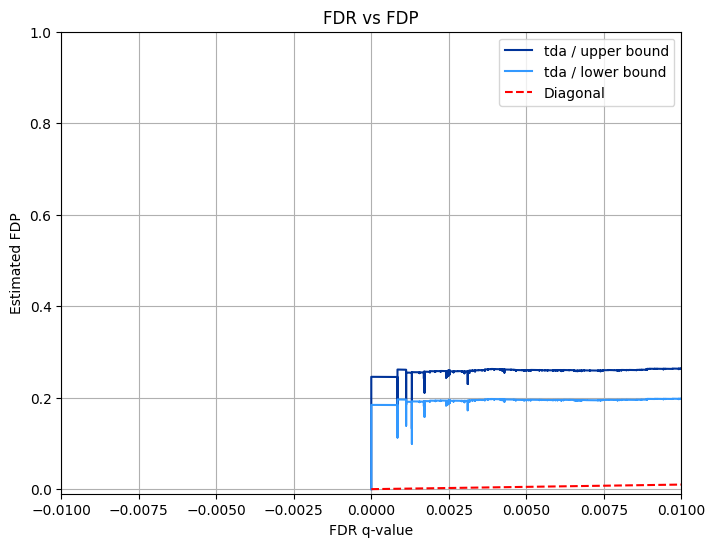

In [40]:

#percolated_df
#percolated_rescored_df
# plotting
plt.figure(figsize=(8, 6))

plt.xlabel("FDR q-value")
plt.ylabel("Estimated FDP")
plt.title("FDR vs FDP")
plt.grid(True)

plt.xlim(-0.01, 0.01)
plt.ylim(bottom=-0.01)
#plt.ylim(0, 0.02)

plt.plot(tda_df["q-value"], tda_df["fdp_ub"], label='tda / upper bound', color='#003399')
plt.plot(tda_df["q-value"], tda_df["fdp_lb"], label='tda / lower bound', color='#3399FF')


# Add a diagonal line
max_diagonal = max(max(tda_df["q-value"]), max(tda_df["fdp_ub"]), max(tda_df["fdp_lb"]))
plt.plot([0, max_diagonal], [0, max_diagonal], color='red', linestyle='--', label='Diagonal')

# Add legend
plt.legend()

plt.show()